In [1]:
import pandas as pd

rates = pd.read_csv("../user_movie_rates.csv")
users = pd.read_csv("../users.csv")
movies = pd.read_csv("../movies.csv")

age_groups = pd.read_csv("../age_groups.csv")
occupations = pd.read_csv("../occupations.csv")

movie_genres = pd.read_csv("../movie_genres.csv")
genres = pd.read_csv("../genres.csv")

movie_actors = pd.read_csv("../movie_actors.csv")
actors = pd.read_csv("../actors.csv")

movie_directors = pd.read_csv("../movie_directors.csv")
directors = pd.read_csv("../directors.csv")

movie_countries = pd.read_csv("../movie_countries.csv")
countries = pd.read_csv("../countries.csv")

print("rates:", rates.shape, rates.columns.tolist())
print("users:", users.shape, users.columns.tolist())
print("movies:", movies.shape, movies.columns.tolist())

print("age_groups:", age_groups.shape, age_groups.columns.tolist())
print("occupations:", occupations.shape, occupations.columns.tolist())

print("movie_genres:", movie_genres.shape, movie_genres.columns.tolist())
print("genres:", genres.shape, genres.columns.tolist())

print("movie_actors:", movie_actors.shape, movie_actors.columns.tolist())
print("actors:", actors.shape, actors.columns.tolist())

print("movie_directors:", movie_directors.shape, movie_directors.columns.tolist())
print("directors:", directors.shape, directors.columns.tolist())

print("movie_countries:", movie_countries.shape, movie_countries.columns.tolist())
print("countries:", countries.shape, countries.columns.tolist())

rates: (948367, 4) ['user_id', 'movie_id', 'rating', 'datetime']
users: (6040, 4) ['user_id', 'gender', 'occupation', 'age_group_id']
movies: (3433, 7) ['movie_id', 'title', 'year', 'rated', 'plot', 'imdb_rating', 'imdb_id']
age_groups: (7, 2) ['group_id', 'group_label']
occupations: (21, 2) ['occ_id', 'occ_name']
movie_genres: (6408, 2) ['movie_id', 'genre_id']
genres: (18, 2) ['genre_id', 'name']
movie_actors: (10285, 2) ['movie_id', 'actor_id']
actors: (4965, 2) ['actor_id', 'actor']
movie_directors: (3676, 2) ['movie_id', 'director_id']
directors: (1918, 2) ['director_id', 'director']
movie_countries: (4765, 2) ['movie_id', 'country_id']
countries: (84, 2) ['country_id', 'country']


In [2]:
import numpy as np

rates_data = rates[["user_id", "movie_id", "rating"]].copy()
rates_data["rating"] = pd.to_numeric(rates_data["rating"])

rates_data.head()

,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5


## Добавляем контентный блок

In [3]:
import numpy as np

def build_content_preference_features(
    data,
    user_col,
    feature_col,
    rating_col,
    selected_features,
    prefix,
    alpha=5
):
    """
    Формирует один интегральный признак для каждой контентной сущности:
    feature_pref = share * smoothed_relative_mean
    """

    # 1. Количество взаимодействий пользователя с каждым признаком
    counts = (
        data
        .groupby([user_col, feature_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=selected_features, fill_value=0)
    )

    # 2. Доля признака среди всех признаков пользователя
    share = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    # 3. Средняя оценка пользователя для каждого признака
    mean_rating = (
        data
        .groupby([user_col, feature_col])[rating_col]
        .mean()
        .unstack()
        .reindex(columns=selected_features)
    )

    # 4. Средняя оценка пользователя в целом
    user_mean_rating = (
        data
        .groupby(user_col)[rating_col]
        .mean()
        .reindex(counts.index)
    )

    # 5. Отклонение оценки признака от средней оценки пользователя
    relative_mean = mean_rating.sub(user_mean_rating, axis=0).fillna(0)

    # 6. Сглаживание: редкие признаки не должны слишком сильно влиять
    smoothing = counts / (counts + alpha)

    # 7. Интегральный признак
    pref = share * relative_mean * smoothing

    pref.columns = [f"{prefix}_pref__{c}" for c in pref.columns]

    return pref.reset_index()

### Жанры

In [4]:
genre_data = (
    rates_data
    .merge(movie_genres, on="movie_id", how="inner")
    .merge(genres, on="genre_id", how="left")
)

genre_data.head()

,user_id,movie_id,rating,genre_id,name
0,1,1193,5,8,Drama
1,1,661,3,3,Animation
2,1,661,3,4,Children's
3,1,661,3,12,Musical
4,1,914,3,12,Musical


Считаем долю жанров пользователя

In [5]:
genre_counts = (
    genre_data
    .groupby(["user_id", "name"])
    .size()
    .unstack(fill_value=0)
)

genre_counts.head()

name,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,
1,5,5,18,20,14,2,0,21,3,0,0,14,0,6,3,3,2,0
2,54,19,0,0,25,11,0,76,1,1,2,0,3,24,17,30,15,3
3,22,24,3,3,28,0,0,8,2,0,2,1,1,5,6,5,2,6
4,19,6,0,1,0,1,0,6,2,0,3,0,0,2,9,4,3,2
5,29,8,1,5,50,18,6,98,0,2,9,3,7,28,13,35,6,1


In [6]:
genre_popularity = genre_counts.sum(axis=0).sort_values(ascending=False)
top_genres = genre_popularity.index
ac_counts = genre_counts[top_genres]

In [7]:
user_genre = build_content_preference_features(
    data=genre_data,
    user_col="user_id",
    feature_col="name",
    rating_col="rating",
    selected_features=top_genres,
    prefix="genre",
    alpha=5
)

df_users = user_genre

print("Размер таблицы после жанров:", df_users.shape)

Размер таблицы после жанров: (6040, 19)


Объединяем жанровый блок

In [8]:
user_genre.head()

,user_id,genre_pref__Drama,genre_pref__Comedy,genre_pref__Action,genre_pref__Thriller,genre_pref__Sci-Fi,genre_pref__Romance,genre_pref__Adventure,genre_pref__Crime,genre_pref__Horror,genre_pref__Children's,genre_pref__War,genre_pref__Musical,genre_pref__Mystery,genre_pref__Animation,genre_pref__Fantasy,genre_pref__Western,genre_pref__Film-Noir,genre_pref__Documentary
0,1,0.033674,-0.004928,0.000037,-0.005156,0.001310,-0.014998,-0.004273,-0.000977,0.000000,0.007134,0.003949,0.007776,0.000000,-0.010585,-0.001923,0.000000,0.000000,0.000000
1,2,0.057275,-0.008084,-0.029731,-0.015469,-0.003777,0.002777,0.003629,-0.003326,-0.001361,0.000000,0.002574,0.000000,-0.001344,0.000000,-0.000397,0.002660,0.000196,0.000000
2,3,0.000000,-0.035953,0.013810,-0.004237,-0.004622,-0.004237,0.021040,0.000000,-0.002421,0.000000,0.000000,0.000000,-0.001412,0.000000,0.002421,0.018490,0.000000,0.000000
3,4,0.010377,0.000000,0.045420,-0.014797,-0.042615,0.000170,-0.008432,0.002923,0.006800,0.000050,-0.012597,0.000000,0.000000,0.000000,0.005096,0.005096,0.000000,0.000000
4,5,-0.013941,0.042872,-0.043996,-0.027894,-0.003506,-0.003552,-0.003768,0.016819,-0.002161,0.006903,0.003908,0.000755,0.000304,0.000983,0.000000,0.000460,0.001578,0.005617


### Актеры и режиссеры

Для атрибутов с высокой кардинальностью (actors, directors) используем фильтрация по популярности, это позволит уменьшить разреженность матрицы признаков и повысить устойчивость кластеризации

In [9]:
actor_data = (
    rates_data
    .merge(movie_actors, on="movie_id", how="inner")
    .merge(actors, on="actor_id", how="left")
)

actor_data.head()

,user_id,movie_id,rating,actor_id,actor
0,1,1193,5,210,Jack Nicholson
1,1,1193,5,1431,Louise Fletcher
2,1,1193,5,1951,Michael Berryman
3,1,661,3,1167,Paul Terry
4,1,661,3,1168,Joanna Lumley


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_topk_coverage_percent(df, entity_col, k_max=500, step=10, title=None):

    counts = df[entity_col].value_counts()
    total_links = len(df)

    k_values = list(range(step, k_max + 1, step))
    coverage_percent = []

    for k in k_values:
        covered = counts.head(k).sum()
        coverage_percent.append(covered / total_links * 100)

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, coverage_percent, marker='o')

    plt.xlabel("K (топ сущностей)")
    plt.ylabel("Покрытие (%)")

    if title:
        plt.title(title)
    else:
        plt.title(f"Покрытие связей для {entity_col}")

    for x, y in zip(k_values, coverage_percent):
        plt.text(x, y + 0.5, f"{y:.1f}%", ha='center', fontsize=8)

    plt.grid(alpha=0.3)
    plt.show()

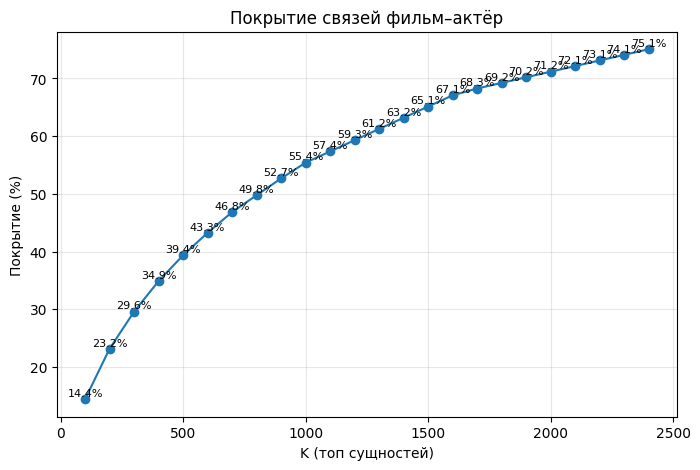

In [11]:
plot_topk_coverage_percent(movie_actors, "actor_id", len(actors)//2, step=100, title="Покрытие связей фильм–актёр")

In [12]:
actor_counts = (
    actor_data
    .groupby(["user_id", "actor"])
    .size()
    .unstack(fill_value=0)
)

In [13]:
actor_popularity = actor_counts.sum(axis=0).sort_values(ascending=False)

TOP_K_ACTORS = 500
top_actors = actor_popularity.head(TOP_K_ACTORS).index
actor_counts = actor_counts[top_actors]

print(f"Оставили актёров (top-{TOP_K_ACTORS}):", len(top_actors))

Оставили актёров (top-500): 500


In [14]:
user_actor = build_content_preference_features(
    data=actor_data,
    user_col="user_id",
    feature_col="actor",
    rating_col="rating",
    selected_features=top_actors,
    prefix="actor",
    alpha=5
)

df_users = (
    df_users
    .merge(user_actor, on="user_id", how="left")
    .fillna(0)
)

print("Размер таблицы после актёров:", df_users.shape)

user_actor.head()

Размер таблицы после актёров: (6040, 519)


,user_id,actor_pref__Harrison Ford,actor_pref__Tom Hanks,actor_pref__Robert De Niro,actor_pref__Mel Gibson,actor_pref__Arnold Schwarzenegger,actor_pref__Gene Hackman,actor_pref__Bruce Willis,actor_pref__Sigourney Weaver,actor_pref__Al Pacino,...,actor_pref__Donald Pleasence,actor_pref__Ossie Davis,actor_pref__Marcia Strassman,actor_pref__John Wayne,actor_pref__Randy Quaid,actor_pref__Joe Pantoliano,actor_pref__Delroy Lindo,actor_pref__Elizabeth Berridge,actor_pref__Iben Hjejle,actor_pref__Debbie Reynolds
0,1,-0.000381,0.009913,0.001355,0.001355,0.000000,-0.000381,-0.000381,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1,2,0.001444,0.005094,-0.006219,0.000246,0.001178,-0.002913,-0.001018,-0.001479,-0.000432,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000781,0.0,0.0
2,3,0.011858,-0.001329,0.000000,0.000000,0.000000,0.001570,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,4,-0.016314,0.002811,0.000000,-0.000661,-0.014172,0.000000,-0.000661,-0.000661,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
4,5,-0.000643,-0.005601,-0.002939,0.000000,-0.004123,-0.000288,-0.000288,-0.003084,-0.000897,...,0.0,0.0,0.0,0.0,0.0,0.000475,0.0,0.000000,0.0,0.0


In [15]:
director_data = (
    rates_data
    .merge(movie_directors, on="movie_id", how="inner")
    .merge(directors, on="director_id", how="left")
)

director_data

,user_id,movie_id,rating,director_id,director
0,1,1193,5,770,Milos Forman
1,1,661,3,425,Henry Selick
2,1,914,3,647,George Cukor
3,1,3408,4,291,Steven Soderbergh
4,1,2355,5,1,John Lasseter
...,...,...,...,...,...
1027846,6040,1091,1,758,Ted Kotcheff
1027847,6040,1094,5,229,Neil Jordan
1027848,6040,562,5,435,Todd Solondz
1027849,6040,1096,4,760,Alan J. Pakula


In [16]:
director_counts = (
    director_data
    .groupby(["user_id", "director"])
    .size()
    .unstack(fill_value=0)
)

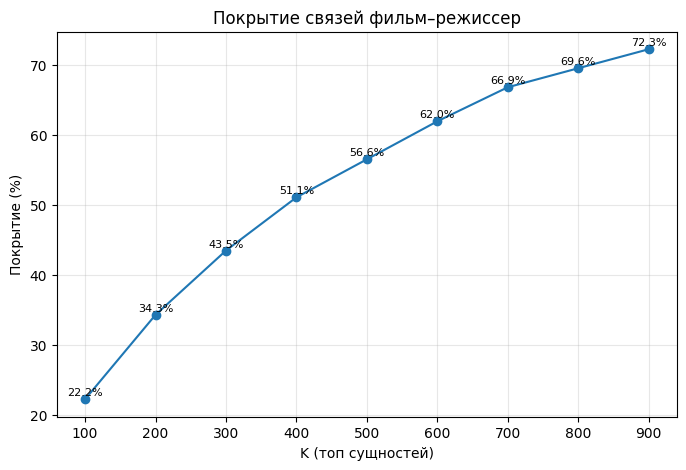

In [17]:
plot_topk_coverage_percent(movie_directors, "director_id", len(directors)//2, step=100, title="Покрытие связей фильм–режиссер")

In [18]:
director_popularity = director_counts.sum(axis=0).sort_values(ascending=False)

TOP_K_DIRECTORS = 400
top_directors = director_popularity.head(TOP_K_DIRECTORS).index
director_counts = director_counts[top_directors]

print(f"Оставили режиссеров (top-{TOP_K_DIRECTORS}):", len(top_directors))

Оставили режиссеров (top-400): 400


In [19]:
user_director = build_content_preference_features(
    data=director_data,
    user_col="user_id",
    feature_col="director",
    rating_col="rating",
    selected_features=top_directors,
    prefix="director",
    alpha=5
)

df_users = (
    df_users
    .merge(user_director, on="user_id", how="left")
    .fillna(0)
)

print("Размер таблицы после режиссёров:", df_users.shape)

Размер таблицы после режиссёров: (6040, 919)


### Страны

In [20]:
country_data = (
    rates_data
    .merge(movie_countries, on="movie_id", how="inner")
    .merge(countries, on="country_id", how="left")
)

country_data.head()

,user_id,movie_id,rating,country_id,country
0,1,1193,5,1,United States
1,1,661,3,3,United Kingdom
2,1,661,3,1,United States
3,1,914,3,1,United States
4,1,3408,4,1,United States


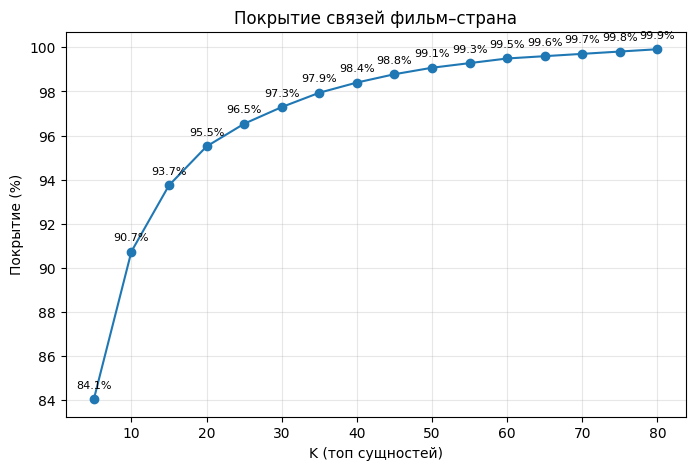

In [21]:
plot_topk_coverage_percent(movie_countries, "country_id", len(countries), step=5, title="Покрытие связей фильм–страна")

In [22]:
country_counts = (
    country_data
    .groupby(["user_id", "country"])
    .size()
    .unstack(fill_value=0)
)

In [23]:
country_popularity = country_counts.sum(axis=0).sort_values(ascending=False)

TOP_K_COUNTRIES = 20
top_countries = country_popularity.head(TOP_K_COUNTRIES).index
country_counts = country_counts[top_countries]

print(f"Оставили страны (top-{TOP_K_COUNTRIES}):", len(top_countries))

Оставили страны (top-20): 20


In [24]:
user_country = build_content_preference_features(
    data=country_data,
    user_col="user_id",
    feature_col="country",
    rating_col="rating",
    selected_features=top_countries,
    prefix="country",
    alpha=5
)

df_users = (
    df_users
    .merge(user_country, on="user_id", how="left")
    .fillna(0)
)

print("Размер таблицы после стран:", df_users.shape)

Размер таблицы после стран: (6040, 939)


## Стандартизация

In [25]:
X = df_users.drop(columns=["user_id"])

In [26]:
X = X.fillna(0)

In [27]:
X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
genre_pref__Drama,6040.0,0.020116,0.034737,-0.224575,-0.000716,0.017137,0.037941,0.290421
genre_pref__Comedy,6040.0,-0.005635,0.031349,-0.342112,-0.021808,-0.005633,0.010171,0.228849
genre_pref__Action,6040.0,-0.004752,0.021788,-0.165689,-0.016613,-0.004407,0.006596,0.146801
genre_pref__Thriller,6040.0,0.000737,0.018510,-0.100559,-0.008685,0.000575,0.010169,0.138692
genre_pref__Sci-Fi,6040.0,-0.005622,0.015840,-0.155128,-0.012873,-0.003884,0.002015,0.201796


In [28]:
(X.sum(axis=1) == 0).sum()

np.int64(1)

# K-Mean

In [29]:
X_clust = X

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []

for k in range(7, 16):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_clust)

    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_clust, labels),
        "calinski_harabasz": calinski_harabasz_score(X_clust, labels),
        "davies_bouldin": davies_bouldin_score(X_clust, labels)
    })

scores_df = pd.DataFrame(results)
scores_df

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,7,37.783714,0.074523,582.111381,2.178325
1,8,36.773731,0.071879,536.238079,2.120227
2,9,36.595238,0.071687,475.095722,1.909021
3,10,35.910156,0.062525,443.074633,1.967363
4,11,35.260491,0.056703,417.155278,1.982840
5,12,34.860282,0.053192,389.813401,2.076398
6,13,34.184389,0.053634,374.264087,2.059895
7,14,33.788784,0.049677,354.888617,2.138782
8,15,33.512708,0.047910,335.744287,2.185986


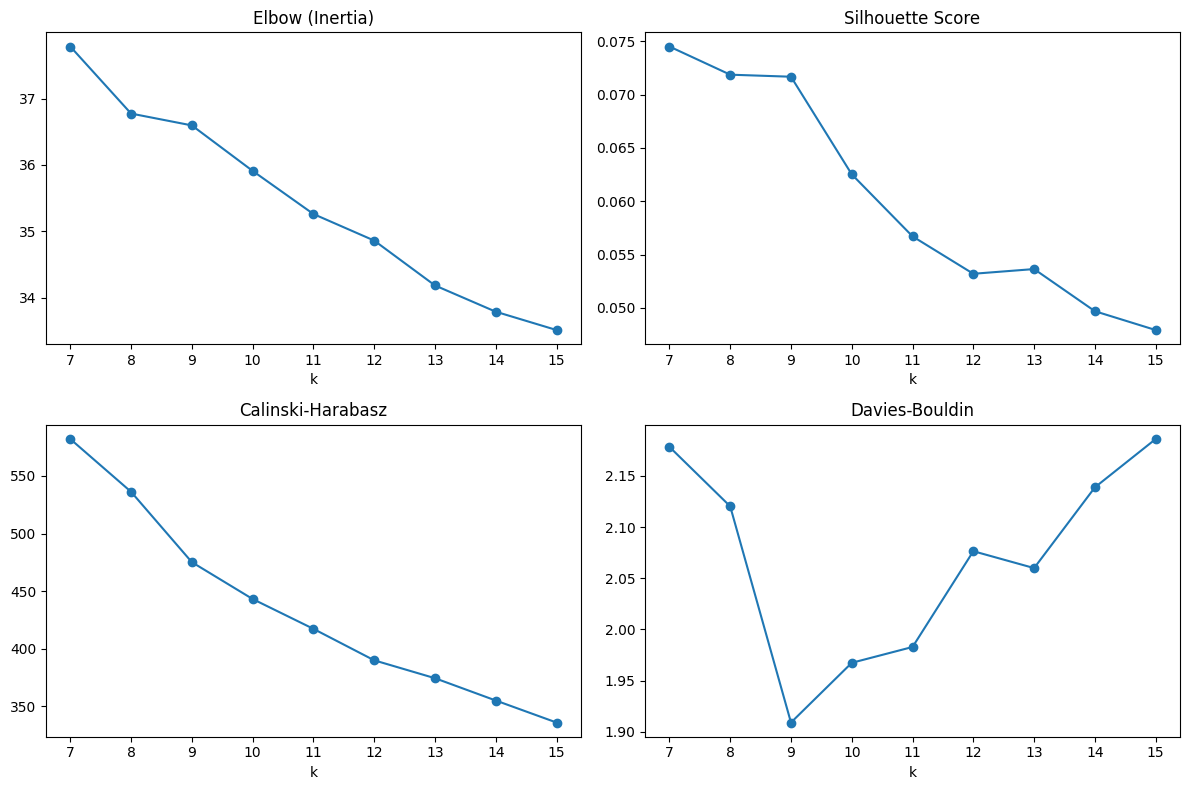

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Inertia
axes[0, 0].plot(scores_df["k"], scores_df["inertia"], marker="o")
axes[0, 0].set_title("Elbow (Inertia)")
axes[0, 0].set_xlabel("k")

# Silhouette
axes[0, 1].plot(scores_df["k"], scores_df["silhouette"], marker="o")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("k")

# Calinski-Harabasz
axes[1, 0].plot(scores_df["k"], scores_df["calinski_harabasz"], marker="o")
axes[1, 0].set_title("Calinski-Harabasz")
axes[1, 0].set_xlabel("k")

# Davies-Bouldin
axes[1, 1].plot(scores_df["k"], scores_df["davies_bouldin"], marker="o")
axes[1, 1].set_title("Davies-Bouldin")
axes[1, 1].set_xlabel("k")

plt.tight_layout()
plt.show()

1. Inertia
- Плавное убывание c небольшим замедление примерно после: k ≈ 8–9
2. Silhouette
- максимум в этом диапазоне — k=7 потом k = 8
3. Davies-Bouldin
- Лучшие значения (минимум) около: k = 8, 12, 14
4. Calinski-Harabasz
- Максимум при k=7 и резкое падение при k= 8.

С учётом всего, разумный рабочий диапазон: k = 7–12

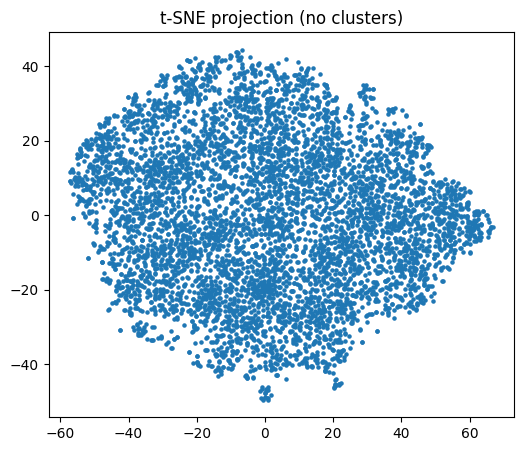

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_clust)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], s=5)
plt.title("t-SNE projection (no clusters)")
plt.show()

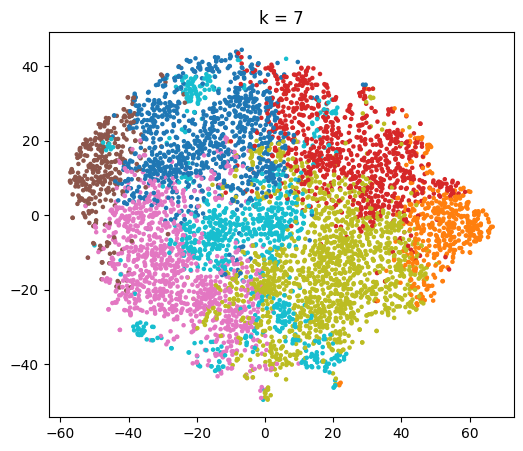

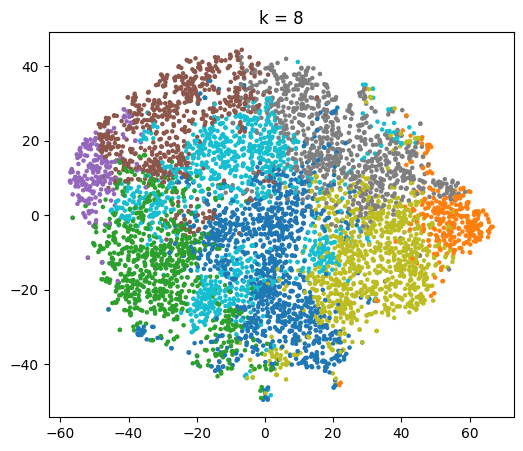

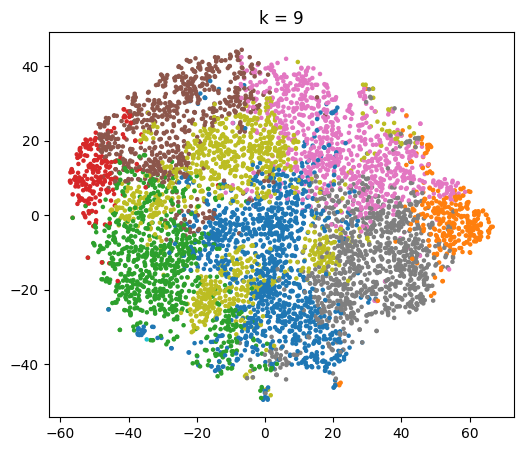

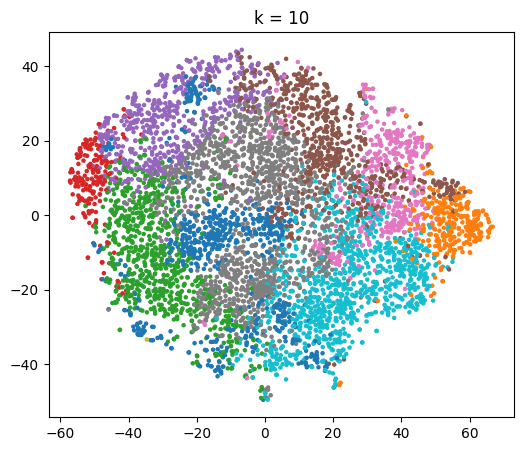

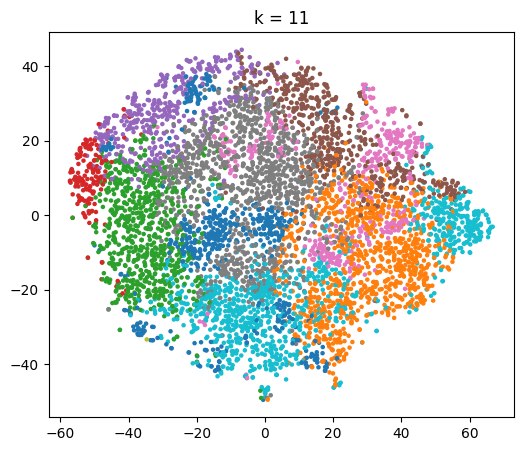

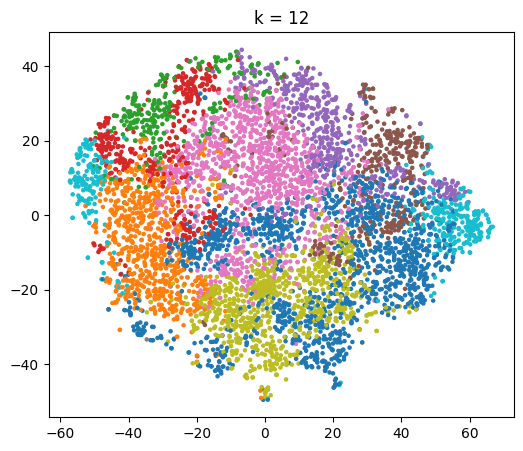

In [33]:
for k in range(7, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_clust)

    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=5, cmap="tab10")
    plt.title(f"k = {k}")
    plt.show()

In [34]:
from sklearn.cluster import KMeans

k = 8
kmeans8 = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels8 = kmeans8.fit_predict(X_clust)

df_users["cluster_k8"] = labels8

In [35]:
cluster_k8_sizes = df_users["cluster_k8"].value_counts().sort_index()
cluster_k8_sizes

cluster_k8
0    1153
1     313
2     793
3     222
4     704
5     855
6     955
7    1045
Name: count, dtype: int64

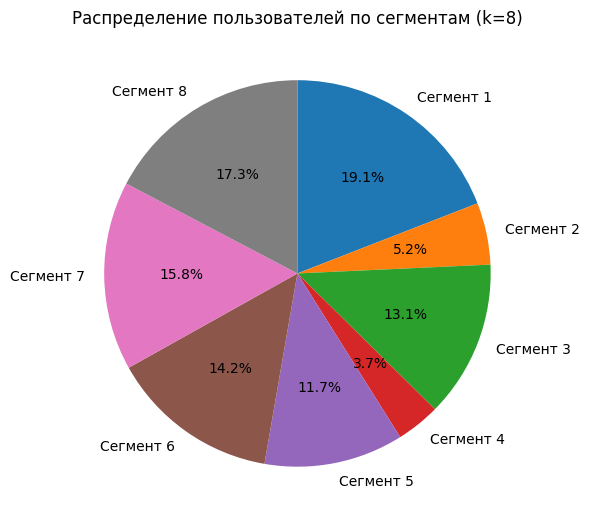

In [36]:
plt.figure(figsize=(6, 6))
plt.pie(
    cluster_k8_sizes,
    labels=[f"Сегмент {i + 1}" for i in cluster_k8_sizes.index],
    autopct="%.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Распределение пользователей по сегментам (k=8)")
plt.tight_layout()
plt.show()

# Профили пользователей кластеров по вкусовым предпочтениям

In [44]:
rows = []

for cluster_id, row in cluster_genres.iterrows():
    # берём только положительные
    pos = row[row > 0]

    total = pos.sum()

    for feature, value in pos.items():
        genre = feature.replace("genre_pref__", "")
        percent = (value / total * 100) if total > 0 else 0

        rows.append({
            "cluster": cluster_id,
            "genre": genre,
            "preference_score": value,
            "preference_percent": percent
        })

top_genres_df = pd.DataFrame(rows)

top_genres_df["preference_percent"] = top_genres_df["preference_percent"].round(2)

In [45]:
top_genres_df

,cluster,genre,preference_score,preference_percent
0,0,Drama,0.015920,37.82
1,0,Action,0.007470,17.75
2,0,Thriller,0.006754,16.05
3,0,Adventure,0.000646,1.53
4,0,Crime,0.002585,6.14
...,...,...,...,...
80,7,Mystery,0.000136,0.29
81,7,Animation,0.002036,4.38
82,7,Western,0.000136,0.29
83,7,Film-Noir,0.001084,2.33


#### Кластер 1 — Серьёзный динамический профиль

- Drama = 37.82%
- Action = 17.75%
- Thriller = 16.05%
- War = 14.59%
- Crime = 6.14%

Сегмент сочетает интерес к серьёзному сюжетному контенту с тяготением к динамичным и напряжённым жанрам. Пользователи этого кластера предпочитают фильмы с конфликтом, эмоциональной составляющей и активным развитием событий.

#### Кластер 2 — Сюжетно-конфликтный профиль
- Drama = 44.85%
- War = 14.12%
- Comedy = 13.90%
- Crime = 10.40%
- Film-Noir = 9.38%

Для данного сегмента характерен интерес к сюжетно насыщенным фильмам, часто связанным с конфликтом, криминальной или военной тематикой. Заметную роль играют комедия, криминал и нуар. Это говорит о более смешанном характере предпочтений.

#### Кластер 3 — Экшен-триллерный профиль
- Thriller = 27.45%
- Action = 25.71%
- War = 16.19%
- Crime = 7.54%
- Film-Noir = 6.73%

Этот кластер ориентирован на напряжённые и динамичные жанры. Наиболее значимыми являются триллер и экшен, что указывает на предпочтение фильмов с высокой интенсивностью событий, конфликтом и элементами опасности. Военная и криминальная тематики усиливают общий характер сегмента.

#### Кластер 4 — Выраженный драматический профиль
- Drama = 78.24%
- War = 5.54%
- Crime = 5.19%
- Documentary = 3.32%
- Film-Noir = 2.71%

Сегмент имеет наиболее выраженную жанровую концентрацию: подавляющая часть предпочтений связана с драмой. Остальные жанры играют вспомогательную роль и в основном дополняют драматическую направленность через военную, криминальную, документальную или нуарную тематику.

#### Кластер 5 — Драматический профиль с конфликтной тематикой
- Drama = 76.65%
- War = 8.93%
- Crime = 6.01%
- Film-Noir = 2.78%
- Mystery = 1.93%

Данный сегмент также является преимущественно драматическим, однако по сравнению с кластером 4 в нём сильнее выражены военная и криминальная составляющие. Пользователи этого сегмента предпочитают фильмы с серьёзным конфликтом, напряжённой атмосферой и более мрачной сюжетной структурой.

#### Кластер 6 — Драматический профиль с мягким жанровым окружением
- Drama = 68.29%
- War = 9.20%
- Crime = 6.09%
- Comedy = 5.08%
- Romance = 4.20%

В этом кластере драма также занимает центральное место, но профиль выглядит мягче и разнообразнее за счёт присутствия комедии и романтики. Пользователи ориентированы на эмоционально насыщенные фильмы, при этом положительно воспринимают более личные, бытовые или межличностные сюжетные линии.

#### Кластер 7 — Динамично-приключенческий профиль
- Action = 24.47%
- War = 18.96%
- Thriller = 13.32%
- Film-Noir = 9.17%
- Adventure = 7.63%

Этот сегмент отличается более равномерным распределением предпочтений между несколькими жанрами. В отличие от драматических кластеров, здесь лидируют экшен, военная тематика и триллер. Пользователи ориентированы на зрелищные, конфликтные и напряжённые фильмы, а также проявляют интерес к приключенческому контенту.

#### Кластер 8 — Комедийно-эмоциональный профиль
- Comedy = 45.67%
- Drama = 27.33%
- Romance = 7.34%
- War = 6.25%
- Animation = 4.38%

Сегмент ориентирован преимущественно на комедийный контент. Это говорит о склонности пользователей к более лёгким и эмоционально доступным фильмам, где развлекательная составляющая сочетается с сюжетной или личностной глубиной. Наличие романтики и анимации дополнительно подчёркивает более мягкий и массовый характер профиля.

In [47]:
country_pref_cols = [c for c in df_users.columns if c.startswith("country_pref__")]

cluster_countries = (
    df_users
    .groupby("cluster_k8")[country_pref_cols]
    .mean()
    .sort_index()
)

rows = []

for cluster_id, row in cluster_countries.iterrows():
    # берём только положительные значения предпочтений
    pos = row[row > 0]

    total = pos.sum()

    for feature, value in pos.items():
        country = feature.replace("country_pref__", "")

        percent = (value / total * 100) if total > 0 else 0

        rows.append({
            "cluster": cluster_id,
            "country": country,
            "preference_score": value,
            "preference_percent": percent
        })

top_countries_df = pd.DataFrame(rows)

top_countries_df["preference_score"] = top_countries_df["preference_score"].round(4)
top_countries_df["preference_percent"] = top_countries_df["preference_percent"].round(2)

top_countries_df = top_countries_df.sort_values(
    ["cluster", "preference_percent"],
    ascending=[True, False]
).reset_index(drop=True)

top_countries_df

,cluster,country,preference_score,preference_percent
0,0,United States,0.0039,39.67
1,0,United Kingdom,0.0038,38.81
2,0,Italy,0.0006,6.56
3,0,France,0.0004,3.76
4,0,Spain,0.0003,3.37
...,...,...,...,...
75,7,Austria,0.0001,1.14
76,7,Australia,0.0001,1.03
77,7,Ireland,0.0001,0.97
78,7,China,0.0000,0.23


#### Сегмент 1 — Англо-американский профиль с европейским фоном
- United States = 39.67%
- United Kingdom = 38.81%
- Italy = 6.56%
- France = 3.76%
- Spain = 3.37%

Сегмент имеет почти равномерный баланс между американским и британским кино. При этом заметен небольшой вклад европейских стран, прежде всего Италии, Франции и Испании.

#### Сегмент 2 — Чистый американский профиль
- United States = 100.00%

Для данного сегмента характерна полная концентрация положительных предпочтений на фильмах производства США. Это указывает на выраженную ориентацию пользователей на массовый американский кинематограф.

#### Сегмент 3 — Британский профиль с европейским окружением
- United Kingdom = 64.19%
- France = 12.79%
- Italy = 6.96%
- Spain = 3.06%
- Germany = 2.84%

Основу сегмента составляет британское кино, однако заметную роль также играют французские и итальянские фильмы. Профиль можно охарактеризовать как европейско-ориентированный, с явным доминированием Великобритании.

#### Сегмент 4 — Европейский артхаусно-международный профиль
- United Kingdom = 44.89%
- France = 24.70%
- Italy = 7.69%
- Germany = 5.33%
- Switzerland = 2.69%

Этот сегмент наиболее явно ориентирован на европейский кинематограф. Предпочтения распределены между большим числом стран. Такой профиль можно интерпретировать как аудиторию с более широким международным вкусом

#### Сегмент 5 — Британско-французский европейский профиль
- United Kingdom = 59.32%
- France = 19.31%
- Italy = 8.48%
- West Germany = 2.84%
- Switzerland = 2.57%

Сегмент также относится к европейско-ориентированным, но имеет более выраженное британское ядро. Франция и Италия выступают важными дополнительными направлениями предпочтений. В отличие от более международного сегмента 4, здесь структура предпочтений компактнее и сильнее сконцентрирована вокруг Великобритании и Франции.

#### Сегмент 6 — Американский профиль с минимальным внешним вкладом
- United States = 98.84%
- Morocco = 0.47%
- Italy = 0.28%
- West Germany = 0.28%
- Ireland = 0.07%

Профиль практически полностью ориентирован на американские фильмы. Небольшие значения для других стран не формируют самостоятельного направления предпочтений и могут рассматриваться как слабый дополнительный фон.

#### Сегмент 7 — Максимально концентрированный американский профиль
- United States = 99.81%
- Morocco = 0.19%

Это наиболее однородный по странам сегмент после сегмента 2. Почти вся структура положительных предпочтений связана с американским кино.

#### Сегмент 8 — Британский профиль с умеренным европейским разнообразием
- United Kingdom = 69.47%
- France = 9.19%
- Italy = 8.35%
- Spain = 2.57%
- West Germany = 2.36%

Сегмент характеризуется сильным доминированием британского кино при наличии умеренного вклада других европейских стран.

In [48]:
director_pref_cols = [c for c in df_users.columns if c.startswith("director_pref__")]

cluster_directors = (
    df_users
    .groupby("cluster_k8")[director_pref_cols]
    .mean()
    .sort_index()
)

rows = []

TOP_N = 5

for cluster_id, row in cluster_directors.iterrows():
    # берём только положительные значения предпочтений
    pos = row[row > 0].sort_values(ascending=False).head(TOP_N)

    total = pos.sum()

    for rank, (feature, value) in enumerate(pos.items(), start=1):
        director = feature.replace("director_pref__", "")

        percent = (value / total * 100) if total > 0 else 0

        rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "director": director,
            "preference_score": value,
            "preference_percent": percent
        })

top_directors_df = pd.DataFrame(rows)

top_directors_df["preference_score"] = top_directors_df["preference_score"].round(4)
top_directors_df["preference_percent"] = top_directors_df["preference_percent"].round(2)

top_directors_df = top_directors_df.sort_values(
    ["cluster", "rank"],
    ascending=[True, True]
).reset_index(drop=True)

top_directors_df

,cluster,rank,director,preference_score,preference_percent
0,0,1,Steven Spielberg,0.0068,47.24
1,0,2,Alfred Hitchcock,0.0026,17.99
2,0,3,James Cameron,0.0024,16.36
3,0,4,Francis Ford Coppola,0.0014,9.82
4,0,5,Ridley Scott,0.0012,8.59
5,1,1,Steven Spielberg,0.0041,34.87
6,1,2,Alfred Hitchcock,0.0022,18.98
7,1,3,Rob Reiner,0.0021,17.84
8,1,4,Francis Ford Coppola,0.0020,16.87
9,1,5,Robert Zemeckis,0.0014,11.44


#### Сегмент 1 — Блокбастерно-авторский профиль
- Steven Spielberg = 47.24%
- Alfred Hitchcock = 17.99%
- James Cameron = 16.36%
- Francis Ford Coppola = 9.82%
- Ridley Scott = 8.59%

При этом присутствие Хичкока, Копполы и Ридли Скотта показывает, что аудитория не ограничивается только развлекательным кино, а также положительно воспринимает напряжённые, криминальные и авторски выраженные фильмы.

#### Сегмент 2 — Смешанный классико-развлекательный профиль
- Steven Spielberg = 34.87%
- Alfred Hitchcock = 18.98%
- Rob Reiner = 17.84%
- Francis Ford Coppola = 16.87%
- Robert Zemeckis = 11.44%

Распределение более сбалансировано. Заметны Роб Райнер и Роберт Земекис, связанные с более мягким, драматическим и развлекательным кино. Такой профиль отражает аудиторию с широкими предпочтениями: от классики и криминальной драмы до более массового эмоционального и комедийного кино.

#### Сегмент 3 — Зрелищно-триллерный профиль
- Steven Spielberg = 33.02%
- James Cameron = 22.28%
- Ridley Scott = 17.09%
- Alfred Hitchcock = 16.34%
- Nick Park = 11.27%

Сегмент ориентирован на динамичное, напряжённое и визуально выразительное кино. Высокие позиции Кэмерона и Ридли Скотта указывают на интерес к масштабным фильмам, фантастике, экшену и триллерам.

#### Сегмент 4 — Авторско-стилистический профиль
- Nick Park = 29.46%
- Ridley Scott = 18.31%
- Ethan Coen = 17.48%
- Joel Coen = 17.48%
- Alfred Hitchcock = 17.27%

Этот сегмент наиболее заметно отличается от остальных. В нём лидирует Ник Парк, а также присутствуют братья Коэны. Такой набор указывает на интерес к более узнаваемому авторскому стилю, нестандартной подаче, иронии, саспенсу и жанровым экспериментам.

#### Сегмент 5 — Классический авторский профиль
- Steven Spielberg = 25.62%
- Alfred Hitchcock = 20.77%
- Stanley Kubrick = 20.18%
- Francis Ford Coppola = 19.33%
- Martin Scorsese = 14.11%

Сегмент имеет выраженную ориентацию на признанных классиков кино. Здесь нет одного сверхдоминирующего режиссёра: предпочтения распределены между Спилбергом, Хичкоком, Кубриком, Копполой и Скорсезе. Такой профиль можно интерпретировать как аудиторию, ориентированную на режиссёрски значимое, статусное и культурно закреплённое кино. Это один из наиболее «кинофильских» сегментов по режиссёрскому составу.

#### Сегмент 6 — Массово-драматический профиль
- Steven Spielberg = 40.21%
- Alfred Hitchcock = 18.03%
- Francis Ford Coppola = 17.23%
- Rob Reiner = 13.51%
- Sam Mendes = 11.01%

Коппола и Хичкок добавляют более серьёзную и напряжённую составляющую, Роб Райнер — более мягкий развлекательный и драматический компонент, а Сэм Мендес усиливает современную драматическую линию. Профиль можно описать как массовый

#### Сегмент 7 — Голливудский развлекательный профиль
- Steven Spielberg = 39.68%
- Alfred Hitchcock = 20.26%
- James Cameron = 15.33%
- Rob Reiner = 13.96%
- Robert Zemeckis = 10.77%

Спилберг, Кэмерон и Земекис формируют блок зрелищного и популярного голливудского кино, а Роб Райнер добавляет комедийно-драматический оттенок.

#### Сегмент 8 — Комедийно-анимационный авторский профиль
- Steven Spielberg = 24.68%
- Rob Reiner = 20.77%
- Alfred Hitchcock = 20.50%
- Nick Park = 18.64%
- John Lasseter = 15.41%

Этот сегмент отличается заметным присутствием режиссёров, связанных с комедийным, семейным и анимационным кино: Роб Райнер, Ник Парк и Джон Лассетер. Профиль можно интерпретировать как более мягкий и развлекательный: пользователи положительно воспринимают эмоционально доступное, комедийное и анимационное содержание

In [49]:
actor_pref_cols = [c for c in df_users.columns if c.startswith("actor_pref__")]

cluster_actors = (
    df_users
    .groupby("cluster_k8")[actor_pref_cols]
    .mean()
    .sort_index()
)

rows = []

TOP_N = 5

for cluster_id, row in cluster_actors.iterrows():
    # берём только положительные значения предпочтений
    pos = row[row > 0].sort_values(ascending=False).head(TOP_N)

    total = pos.sum()

    for rank, (feature, value) in enumerate(pos.items(), start=1):
        actor = feature.replace("actor_pref__", "")

        percent = (value / total * 100) if total > 0 else 0

        rows.append({
            "cluster": cluster_id,
            "rank": rank,
            "actor": actor,
            "preference_score": value,
            "preference_percent": percent
        })

top_actors_df = pd.DataFrame(rows)

top_actors_df["preference_score"] = top_actors_df["preference_score"].round(4)
top_actors_df["preference_percent"] = top_actors_df["preference_percent"].round(2)

top_actors_df = top_actors_df.sort_values(
    ["cluster", "rank"],
    ascending=[True, True]
).reset_index(drop=True)

top_actors_df

,cluster,rank,actor,preference_score,preference_percent
0,0,1,Harrison Ford,0.0039,41.35
1,0,2,Tom Hanks,0.0017,17.75
2,0,3,Carrie Fisher,0.0015,16.12
3,0,4,Mark Hamill,0.0014,15.02
4,0,5,Al Pacino,0.0009,9.76
5,1,1,Harrison Ford,0.0027,29.02
6,1,2,Tom Hanks,0.0019,21.14
7,1,3,Carrie Fisher,0.0017,18.07
8,1,4,Kevin Spacey,0.0015,16.32
9,1,5,Mark Hamill,0.0014,15.45


#### Сегмент 1 — Приключенческо-драматический голливудский профиль
- Harrison Ford = 41.35%
- Tom Hanks = 17.75%
- Carrie Fisher = 16.12%
- Mark Hamill = 15.02%
- Al Pacino = 9.76%

Сегмент заметно ориентирован на актёров, связанных с массовым приключенческим и фантастическим кино, прежде всего на Харрисона Форда, Кэрри Фишер и Марка Хэмилла. Такой профиль можно интерпретировать как интерес к узнаваемому голливудскому кино

#### Сегмент 2 — Массовый сюжетно-зрелищный профиль
- Harrison Ford = 29.02%
- Tom Hanks = 21.14%
- Carrie Fisher = 18.07%
- Kevin Spacey = 16.32%
- Mark Hamill = 15.45%

Сегмент также можно описать как аудиторию, ориентированную на массовое, понятное и нарративно сильное кино.

#### Сегмент 3 — Экшен-приключенческий профиль
- Harrison Ford = 45.66%
- Carrie Fisher = 16.83%
- Mark Hamill = 15.76%
- Sean Connery = 11.47%
- Arnold Schwarzenegger = 10.28%

Этот сегмент имеет наиболее выраженную ориентацию на приключенческий и экшен-контент. Шон Коннери и Арнольд Шварценеггер добавляют линию классического экшена и героического кино.

#### Сегмент 4 — Авторско-драматический и камерный профиль
- Kevin Spacey = 29.47%
- Ralph Fiennes = 18.91%
- Peter Sallis = 17.88%
- John Cusack = 17.81%
- Cary Grant = 15.93%

Кевин Спейси и Рэйф Файнс указывают на интерес к драматическому, психологическому и более сложному сюжетному кино. Джон Кьюсак и Кэри Грант добавляют элементы романтической, комедийной и авторской традиции, а Питер Саллис связывает профиль с более мягким и анимационным направлением

#### Сегмент 5 — Криминально-драматический актёрский профиль
- Robert De Niro = 29.95%
- Al Pacino = 21.21%
- Kevin Spacey = 20.00%
- Jack Nicholson = 14.73%
- Harrison Ford = 14.10%

Сегмент имеет выраженную ориентацию на актёров, связанных с криминальной драмой, психологическим напряжением и серьёзным авторским кино. Роберт Де Ниро, Аль Пачино, Кевин Спейси и Джек Николсон формируют ядро профиля, связанное с интенсивной актёрской игрой, конфликтными персонажами и мрачными сюжетами.

#### Сегмент 6 — Сбалансированный голливудско-драматический профиль
- Harrison Ford = 25.14%
- Tom Hanks = 24.05%
- Kevin Spacey = 20.26%
- Robert De Niro = 15.62%
- Al Pacino = 14.94%

Предпочтения распределены между несколькими крупными фигурами американского кино. Это один из наиболее сбалансированных актёрских профилей.

#### Сегмент 7 — Классический приключенческий профиль
- Harrison Ford = 37.70%
- Tom Hanks = 19.38%
- Carrie Fisher = 18.12%
- Mark Hamill = 15.62%
- Humphrey Bogart = 9.18%

Пользователи данного сегмента также ориентированы на узнаваемые экранные образы и классический голливудский нарратив.

#### Сегмент 8 — Комедийно-драматический актёрский профиль
- Harrison Ford = 29.71%
- Tom Hanks = 23.95%
- Kevin Spacey = 22.83%
- Bill Murray = 11.99%
- Cary Grant = 11.52%

Сегмент сочетает массовое голливудское кино с более лёгкой комедийной и романтической традицией. Билл Мюррей и Кэри Грант добавляют комедийность, иронию и более мягкий эмоциональный тон. Такой профиль хорошо согласуется с комедийно-эмоциональной направленностью сегмента.

# Профили пользователей по демографическим данным

In [50]:
df_users = df_users.merge(
    users,
    on="user_id",
    how="left"
)

In [51]:
df_users[["user_id", "cluster_k8", "gender", "occupation", "age_group_id"]].head()

,user_id,cluster_k8,gender,occupation,age_group_id
0,1,5,F,11,1
1,2,5,M,17,7
2,3,0,M,16,3
3,4,0,M,8,5
4,5,7,M,21,3


In [52]:
df_users = df_users.merge(
    age_groups,
    left_on="age_group_id",
    right_on="group_id",
    how="left"
)

df_users = df_users.merge(
    occupations,
    left_on="occupation",
    right_on="occ_id",
    how="left"
)

## Профили пользователей кластеров по полу

In [53]:
gender_dist = pd.crosstab(df_users["cluster_k8"], df_users["gender"], normalize="index")
gender_dist

gender,F,M
cluster_k8,,
0,0.260191,0.739809
1,0.316294,0.683706
2,0.300126,0.699874
3,0.324324,0.675676
4,0.265625,0.734375
5,0.239766,0.760234
6,0.307853,0.692147
7,0.300478,0.699522


<Figure size 800x500 with 0 Axes>

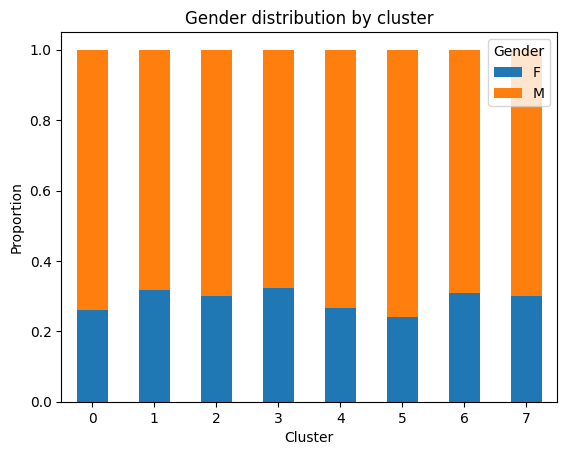

In [54]:
plt.figure(figsize=(8,5))
gender_dist.plot(kind="bar", stacked=True)
plt.title("Gender distribution by cluster")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Gender")
plt.xticks(rotation=0)
plt.show()

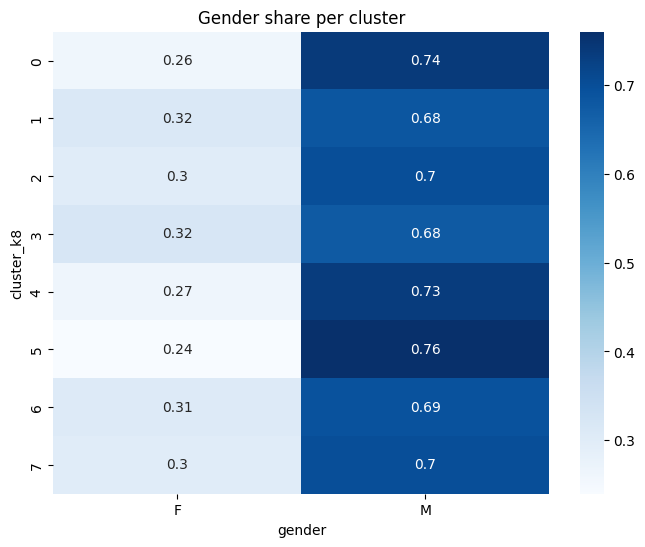

In [55]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(gender_dist, annot=True, cmap="Blues")
plt.title("Gender share per cluster")
plt.show()

Все кластеры преимущественно мужские

## Профили пользователей кластеров по возрастной группе

In [61]:
age_dist = pd.crosstab(df_users["cluster_k8"], df_users["group_label"], normalize="index")
age_dist = age_dist.rename(columns={"under_18": "0_18"})

age_dist = age_dist.sort_index()
age_dist

group_label,18_24,25_34,35_44,45_49,50_55,56_plus,0_18
cluster_k8,,,,,,,
0,0.165655,0.342585,0.194276,0.101474,0.087598,0.074588,0.033825
1,0.194888,0.335463,0.185304,0.083067,0.063898,0.063898,0.073482
2,0.194199,0.319042,0.194199,0.083228,0.108449,0.076923,0.023960
3,0.207207,0.369369,0.175676,0.117117,0.063063,0.040541,0.027027
4,0.183239,0.394886,0.178977,0.065341,0.082386,0.068182,0.026989
5,0.221053,0.341520,0.200000,0.083041,0.070175,0.051462,0.032749
6,0.158115,0.312042,0.236649,0.110995,0.076440,0.056545,0.049215
7,0.174163,0.376077,0.186603,0.088038,0.080383,0.055502,0.039234


<Figure size 1000x600 with 0 Axes>

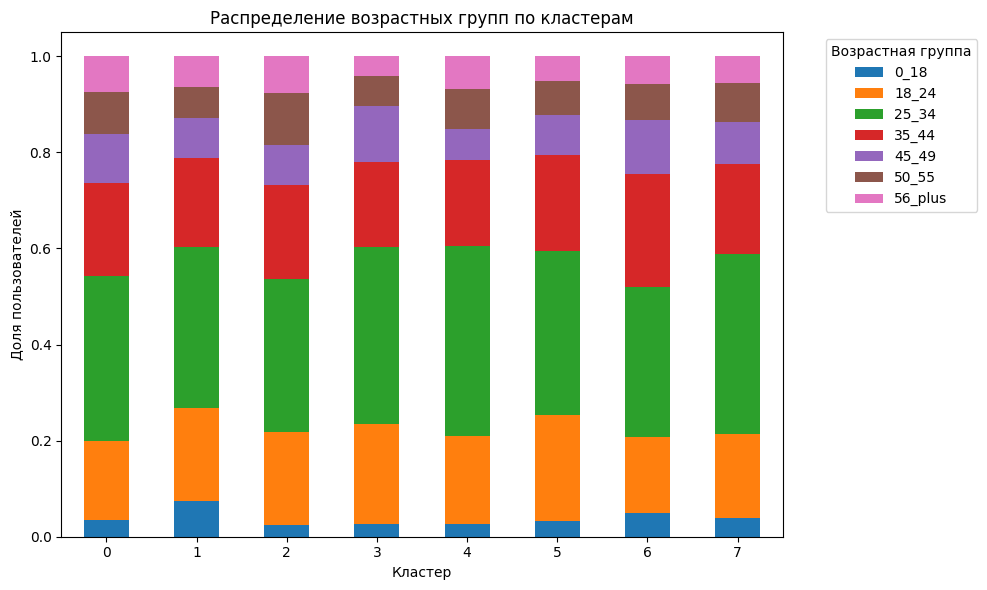

In [62]:
age_order = [
    "0_18",
    "18_24",
    "25_34",
    "35_44",
    "45_49",
    "50_55",
    "56_plus"
]

age_dist_ordered = age_dist[age_order]

plt.figure(figsize=(10, 6))

age_dist_ordered.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Распределение возрастных групп по кластерам")
plt.ylabel("Доля пользователей")
plt.xlabel("Кластер")
plt.xticks(rotation=0)
plt.legend(title="Возрастная группа", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Распределения выглядят достаточно похожими: во всех сегментах основную долю составляют пользователи возрастных групп 25–34 и 35–44, а младшие и старшие группы представлены заметно слабее.

## Профили пользователей кластеров по профессиям

In [63]:
pd.crosstab(df_users["cluster_k8"], df_users["occ_name"], normalize="index")

occ_name,Academic/Educator,Artist,Clerical/Admin,College/Grad student,Customer Service,Doctor/Health care,Executive/Managerial,Farmer,Homemaker,K-12 student,...,Other,Programmer,Retired,Sales/Marketing,Scientist,Self-employed,Technician/engineer,Tradesman/craftsman,Unemployed,Writer
cluster_k8,,,,,,,,,,,,,,,,,,,,,
0,0.065915,0.032090,0.026886,0.119688,0.026886,0.043365,0.124892,0.003469,0.019081,0.027754,...,0.121422,0.058109,0.031223,0.048569,0.019948,0.050304,0.091067,0.018213,0.013010,0.030356
1,0.115016,0.057508,0.047923,0.121406,0.019169,0.051118,0.092652,0.000000,0.022364,0.067093,...,0.092652,0.044728,0.015974,0.060703,0.003195,0.025559,0.086262,0.003195,0.009585,0.044728
2,0.088272,0.047919,0.025221,0.126103,0.008827,0.031526,0.131148,0.002522,0.011349,0.018916,...,0.118537,0.076923,0.027743,0.058008,0.023960,0.036570,0.088272,0.008827,0.008827,0.045397
3,0.135135,0.085586,0.004505,0.135135,0.018018,0.040541,0.099099,0.000000,0.013514,0.018018,...,0.121622,0.072072,0.004505,0.022523,0.036036,0.031532,0.063063,0.009009,0.009009,0.072072
4,0.110795,0.055398,0.026989,0.142045,0.015625,0.042614,0.102273,0.000000,0.008523,0.022727,...,0.125000,0.056818,0.015625,0.053977,0.026989,0.028409,0.068182,0.008523,0.012784,0.061080
5,0.091228,0.035088,0.024561,0.128655,0.017544,0.040936,0.119298,0.004678,0.010526,0.033918,...,0.116959,0.059649,0.021053,0.054971,0.021053,0.046784,0.078363,0.017544,0.012865,0.045614
6,0.069110,0.039791,0.034555,0.106806,0.020942,0.035602,0.100524,0.002094,0.020942,0.043979,...,0.117277,0.080628,0.027225,0.055497,0.026178,0.036649,0.083770,0.011518,0.012565,0.046073
7,0.089952,0.045933,0.031579,0.134928,0.017225,0.035407,0.105263,0.004785,0.015311,0.034450,...,0.115789,0.059330,0.022010,0.036364,0.029665,0.042105,0.087081,0.006699,0.012440,0.051675


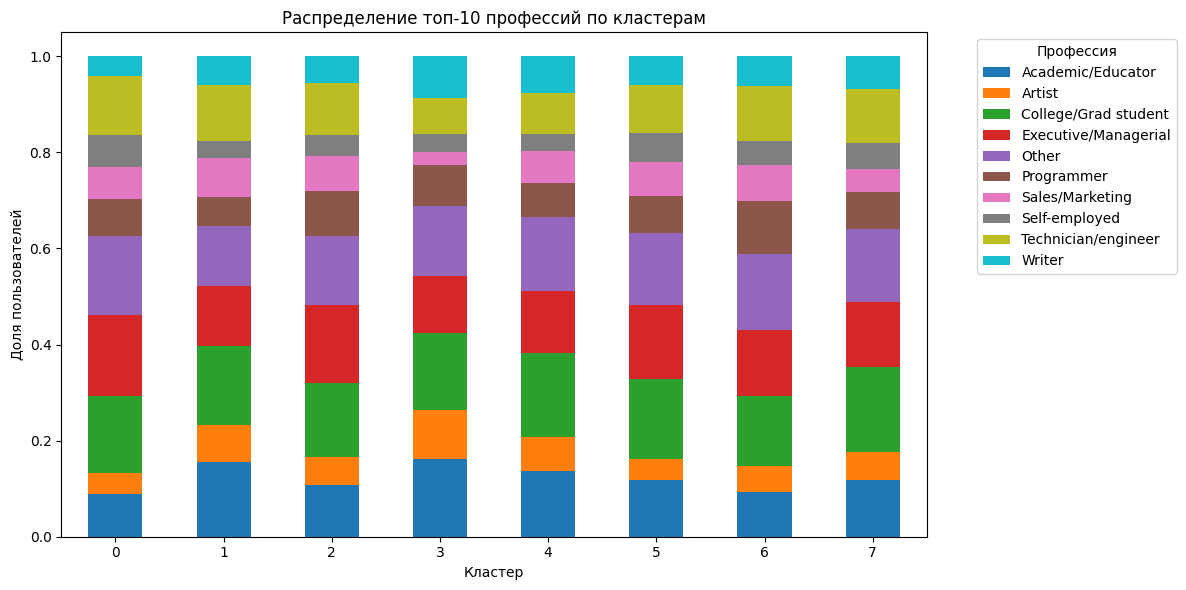

In [65]:
top_occupations = df_users["occ_name"].value_counts().head(10).index

occ_filtered = df_users[df_users["occ_name"].isin(top_occupations)]

occ_dist = pd.crosstab(
    occ_filtered["cluster_k8"],
    occ_filtered["occ_name"],
    normalize="index"
)

ax = occ_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Распределение топ-10 профессий по кластерам")
plt.ylabel("Доля пользователей")
plt.xlabel("Кластер")
plt.xticks(rotation=0)

plt.legend(
    title="Профессия",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Анализ распределения наиболее распространённых профессий по кластерам показывает, что профессиональная структура сегментов в целом является достаточно однородной. Во всех выделенных кластерах представлены основные группы пользователей, включая студентов, преподавателей, специалистов технического профиля, программистов и управленцев. При этом существенного доминирования одной профессиональной категории в отдельных сегментах не наблюдается.

## Резюмируем

### Кластер 1 —

### Кластер 2 —

### Кластер 3 —

### Кластер 4 —

### Кластер 5 —

### Кластер 6 —

### Кластер 7 —

### Кластер 8 —

# RFM - анализ

## Поведенческий портрет пользователя

Для каждого пользователя:
- сколько фильмов он оценил
- средняя оценка
- разброс оценок
- энтропия распределения оценок

In [ ]:
user_basic = (
    rates_data.groupby("user_id")["rating"]
    .agg(
        num_ratings="count",
        mean_rating="mean",
        std_rating="std",
        median_rating="median",
        min_rating="min",
        max_rating="max",
    )
    .reset_index()
)

cnt = (
    rates_data.assign(r_bin=rates_data["rating"].round(2))
    .groupby(["user_id", "r_bin"])
    .size()
    .unstack(fill_value=0)
)

p = cnt.div(cnt.sum(axis=1), axis=0).replace(0, np.nan)

user_entropy = pd.DataFrame({
    "user_id": cnt.index,
    "rating_entropy": ((-(p * np.log(p)).sum(axis=1)) / np.log(5)).fillna(0).values
})

user_basic = (
    user_basic
    .merge(user_entropy, on="user_id", how="left")
    .fillna(0)
)

user_basic.head()

In [ ]:
features_for_corr = df_users[[
    "num_ratings",
    "mean_rating",
    "median_rating",
    "std_rating",
    "min_rating",
    "max_rating",
    "rating_entropy",
    "mean_year",
    "std_year",
    "mean_imdb",
    "std_imdb"
]]

In [ ]:
corr_matrix = features_for_corr.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation matrix of user features")
plt.show()

std_rating и rating_entropy сильно коррелируют (~0.81). Оба показателя отражают вариативность оценок пользователя, то есть насколько пользователь различает фильмы. Из этих двух признаков предпочтительнее использовать rating_entropy, поскольку она лучше интерпретируется как характеристика поведенческого стиля пользователя.

Кроме того, num_ratings практически не коррелирует с другими признаками, что указывает на его независимость. Этот показатель отражает уровень вовлечённости пользователя и естественно соответствует компоненте Frequency в модели RFM.

Таким образом, на основе корреляционного анализа можно выделить три относительно независимые характеристики поведения пользователя:

- Recency — давность последней активности пользователя

- Frequency — количество взаимодействий пользователя (num_ratings)

- Monetary — характер выставления оценок (rating_entropy)

In [ ]:
rates["datetime"] = pd.to_datetime(rates["datetime"])

current_date = rates["datetime"].max()

recency_df = (
    rates.groupby("user_id")["datetime"]
    .max()
    .reset_index()
)

recency_df["recency"] = (current_date - recency_df["datetime"]).dt.days
recency_df = recency_df[["user_id", "recency"]]
recency_df.head()

In [ ]:
df_users = df_users.merge(recency_df, on="user_id", how="left")

In [ ]:
df_users[["user_id","recency"]].head()

In [ ]:
rfm = df_users[[
    "user_id",
    "recency",
    "num_ratings",
    "rating_entropy"
]].copy()

rfm.head()

In [ ]:
rfm.describe()

In [ ]:
rfm[["recency","num_ratings","rating_entropy"]].hist(bins=40, figsize=(12,6))
plt.show()

### Recency

Распределение сильно смещено вправо: большая часть пользователей имеет значения около 800–1000 дней, то есть большинство пользователей давно не проявляли активности. При этом присутствует небольшая группа пользователей с очень низким значением recency (0–100 дней), которые являются наиболее активными и недавно взаимодействовали с системой. Это означает, что в данных присутствует явный дисбаланс между активными и неактивными пользователями.

### Frequency

Распределение имеет выраженный heavy-tail характер: большинство пользователей оставили относительно небольшое количество оценок (до ~200), при этом существует небольшая группа очень активных пользователей (до ~2000 оценок).

### Monetary

Распределение близко к нормальному, с центром примерно в диапазоне 0.7–0.9. Это означает, что большинство пользователей используют достаточно широкий диапазон оценок и различают фильмы при выставлении рейтингов.

In [ ]:
rfm = df_users[["user_id", "recency", "num_ratings", "rating_entropy"]].copy()

quantiles = rfm[["recency","num_ratings","rating_entropy"]].quantile([0.2,0.4,0.6,0.8])
quantiles

In [ ]:
def r_score(x, q):
    if x <= q[0.2]:
        return 5
    elif x <= q[0.4]:
        return 4
    elif x <= q[0.6]:
        return 3
    elif x <= q[0.8]:
        return 2
    else:
        return 1

def fm_score(x, q):
    if x <= q[0.2]:
        return 1
    elif x <= q[0.4]:
        return 2
    elif x <= q[0.6]:
        return 3
    elif x <= q[0.8]:
        return 4
    else:
        return 5

In [ ]:
rfm["R_score"] = rfm["recency"].apply(r_score, q=quantiles["recency"])
rfm["F_score"] = rfm["num_ratings"].apply(fm_score, q=quantiles["num_ratings"])
rfm["M_score"] = rfm["rating_entropy"].apply(fm_score, q=quantiles["rating_entropy"])

In [ ]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm["RFM_sum"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

rfm["RFM_score"].value_counts().head(20)

In [ ]:
rfm_mean_R = (
    rfm.groupby("RFM_score")["recency"]
    .mean()
    .sort_index())

plt.figure(figsize=(18,5))
plt.bar(rfm_mean_R.index, rfm_mean_R.values)

plt.title("Среднее значение Recency (R) по RFM-коду")
plt.xlabel("RFM Score")
plt.ylabel("Mean Recency")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Recency (R)

На графике видно чёткую закономерность:

- RFM-коды с низким R (1xx) имеют очень высокое среднее значение recency (~900–1000) -> эти пользователи очень давно взаимодействовали с системой.

- По мере роста R-оценки среднее значение recency монотонно уменьшается.

- R=5 соответствует пользователям с минимальной давностью активности (примерно 300–400 дней в среднем).

In [ ]:
rfm_mean_F = (
    rfm.groupby("RFM_score")["num_ratings"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(18,5))
plt.bar(rfm_mean_F.index, rfm_mean_F.values)

plt.title("Среднее значение Frequency (F) по RFM-коду")
plt.xlabel("RFM Score")
plt.ylabel("Mean Number of Ratings")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Frequency (F)

На графике очень хорошо видно ступенчатую структуру. Это происходит потому, что F_score построен по квантилям.

Компонента Frequency хорошо разделяет пользователей на:
- низкоактивных
- умеренно активных
- очень активных пользователей

In [ ]:
rfm_mean_M = (
    rfm.groupby("RFM_score")["rating_entropy"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(18,5))
plt.bar(rfm_mean_M.index, rfm_mean_M.values)

plt.title("Среднее значение Monetary (M) по RFM-коду")
plt.xlabel("RFM Score")
plt.ylabel("Mean Rating Entropy")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Monetary (M)

Здесь структура менее ступенчатая, но всё равно прослеживается закономерность.

Среднее значение rating_entropy:
- при M=1 около 0.6–0.7
- при M=5 около 0.9–1.0

Пользователи с низким M ставят очень похожие оценки, пользователи с высоким M активно различают фильмы

## Сегмент 1. Лучшие пользователи
### R: 4-5, F: 4-5, M: 4-5

Пользователи данного сегмента характеризуются высокой активностью по всем трём компонентам RFM. Они недавно взаимодействовали с системой, регулярно оценивают фильмы и активно используют шкалу оценок, различая фильмы по качеству.

## Сегмент 2. Лояльные пользователи
### R: 3-5, F: 4-5, M: 3-5

Данный сегмент включает пользователей, которые регулярно взаимодействуют с системой и оставляют большое количество оценок, однако их последняя активность может быть менее свежей

## Сегмент 3. Потенциально лояльные
### R: 4-5, F: 2–3, M: 3-5

Пользователи этой группы недавно проявляли активность в системе, однако их общее количество взаимодействий пока относительно невелико. Это могут быть новые пользователи или пользователи, которые начали активно использовать платформу сравнительно недавно.

## Сегмент 4. Активные пользователи
### R: 3–4, F: 2–3, M: 2–4

Этот сегмент характеризуется умеренным уровнем активности. Пользователи периодически взаимодействуют с системой и оставляют оценки, однако их активность ниже, чем у лояльных пользователей. Они продолжают пользоваться системой, но не демонстрируют высокой интенсивности взаимодействия.

## Сегмент 5. Под угрозой ухода
### R: 1–2, F: 3–5, M: 3–5

Пользователи данного сегмента в прошлом активно взаимодействовали с системой и оставили заметное количество оценок, однако в последнее время их активность существенно снизилась.

## Сегмент 6. Спящие пользователи
### R: 1–2, F: 1–2, M: 1–3

Этот сегмент включает пользователей, которые давно не взаимодействовали с системой и имеют относительно небольшое количество оценок. Такие пользователи либо потеряли интерес к платформе, либо использовали её лишь эпизодически

In [ ]:
def rfm_segment(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal users"

    elif r >= 4 and f >= 2:
        return "Potential loyalists"

    elif r >= 3 and f >= 2:
        return "Active users"

    elif r <= 2 and f >= 3:
        return "At risk"

    else:
        return "Hibernating"

In [ ]:
rfm["segment"] = rfm.apply(rfm_segment, axis=1)
rfm["segment"].value_counts()

In [ ]:
rfm_seg = rfm['segment'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    rfm_seg,
    labels=[f"Сегмент {i}" for i in rfm_seg.index],
    autopct="%.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Распределение клиентов по сегментам")
plt.tight_layout()
plt.show()

На основе RFM-анализа пользователи системы были разделены на несколько поведенческих сегментов. Наиболее ценными являются пользователи сегмента Champions, которые недавно взаимодействовали с системой, оставили большое количество оценок и активно различают фильмы. Сегмент Loyal users характеризуется стабильной активностью и регулярным взаимодействием с платформой. Пользователи сегмента Potential loyalists проявляют недавнюю активность, но имеют пока ограниченное количество взаимодействий. Сегменты At risk и Hibernating включают пользователей, которые ранее взаимодействовали с системой, но в последнее время не проявляют активности.